In [18]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("Data/Data December 2025.csv")
df.head()

,Sdate,Cosit,Period,LaneNumber,LaneDescription,LaneDirection,DirectionDescription,Volume,Flag Text
0,01/12/2025 00:00,9913,60,2,Eastbound,2,NorthEast,14,Checked
1,01/12/2025 00:00,9913,60,1,Westbound,1,SouthWest,14,Checked
2,01/12/2025 01:00,9913,60,2,Eastbound,2,NorthEast,7,Checked
3,01/12/2025 01:00,9913,60,1,Westbound,1,SouthWest,8,Checked
4,01/12/2025 02:00,9913,60,2,Eastbound,2,NorthEast,5,Checked


In [19]:
df["Sdate"] = pd.to_datetime(df["Sdate"], dayfirst=True, errors="coerce")

df["Hour"] = df["Sdate"].dt.hour
df["Day"] = df["Sdate"].dt.day_name()

df.head()

,Sdate,Cosit,Period,LaneNumber,LaneDescription,LaneDirection,DirectionDescription,Volume,Flag Text,Hour,Day
0,2025-12-01 00:00:00,9913,60,2,Eastbound,2,NorthEast,14,Checked,0,Monday
1,2025-12-01 00:00:00,9913,60,1,Westbound,1,SouthWest,14,Checked,0,Monday
2,2025-12-01 01:00:00,9913,60,2,Eastbound,2,NorthEast,7,Checked,1,Monday
3,2025-12-01 01:00:00,9913,60,1,Westbound,1,SouthWest,8,Checked,1,Monday
4,2025-12-01 02:00:00,9913,60,2,Eastbound,2,NorthEast,5,Checked,2,Monday


In [20]:
hourly_traffic = df.groupby("Hour")["Volume"].mean()
hourly_traffic

Hour
0      29.268683
1      19.711151
2      16.058126
3      15.448992
4      19.573547
5      41.926453
6      79.806413
7     133.678741
8     141.241093
9     131.733533
10    136.462740
11    146.907186
12    156.579450
13    160.387574
14    165.684770
15    167.757379
16    175.366588
17    169.871901
18    144.404959
19    112.952014
20     90.817912
21     73.492289
22     62.561684
23     44.931466
Name: Volume, dtype: float64

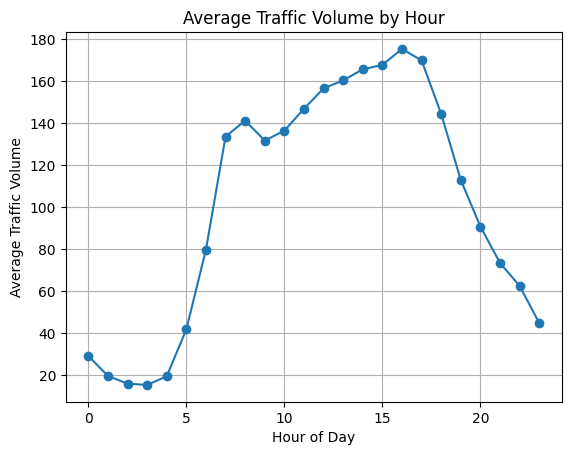

In [21]:
hourly_traffic.plot(kind="line", marker="o")

plt.xlabel("Hour of Day")
plt.ylabel("Average Traffic Volume")
plt.title("Average Traffic Volume by Hour")
plt.grid(True)

plt.show()

In [23]:
df["FixedGreenTime"] = 30
df[["Volume", "FixedGreenTime"]].head()

,Volume,FixedGreenTime
0,14,30
1,14,30
2,7,30
3,8,30
4,5,30


In [25]:
def smart_green_time(volume):
    if volume < 10:
        return 20
    elif volume < 20:
        return 30
    elif volume < 30:
        return 40
    else:
        return 60

In [26]:
df["SmartGreenTime"] = df["Volume"].apply(smart_green_time)
df[["Volume", "FixedGreenTime", "SmartGreenTime"]].head(10)

,Volume,FixedGreenTime,SmartGreenTime
0,14,30,30
1,14,30,30
2,7,30,20
3,8,30,20
4,5,30,20
5,4,30,20
6,8,30,20
7,7,30,20
8,14,30,30
9,13,30,30


In [27]:
df["FixedDelayScore"] = df["Volume"] / df["FixedGreenTime"]
df["SmartDelayScore"] = df["Volume"] / df["SmartGreenTime"]

df[["Volume", "FixedDelayScore", "SmartDelayScore"]].head(10)

,Volume,FixedDelayScore,SmartDelayScore
0,14,0.466667,0.466667
1,14,0.466667,0.466667
2,7,0.233333,0.350000
3,8,0.266667,0.400000
4,5,0.166667,0.250000
5,4,0.133333,0.200000
6,8,0.266667,0.400000
7,7,0.233333,0.350000
8,14,0.466667,0.466667
9,13,0.433333,0.433333


In [28]:
fixed_avg = df["FixedDelayScore"].mean()
smart_avg = df["SmartDelayScore"].mean()

print("Average Fixed Delay Score:", fixed_avg)
print("Average Smart Delay Score:", smart_avg)

Average Fixed Delay Score: 3.38460961332344
Average Smart Delay Score: 1.749500783246764


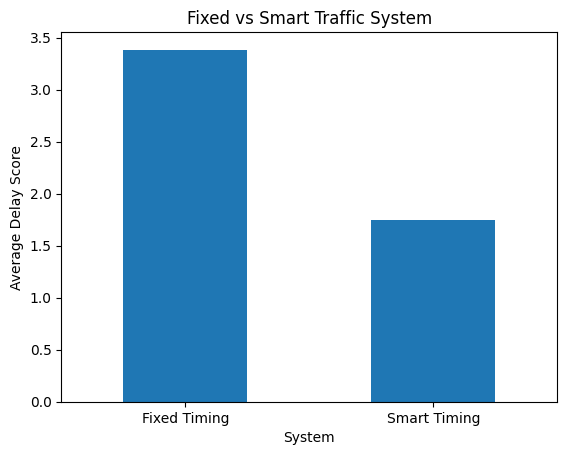

In [29]:
comparison = pd.DataFrame({
    "System": ["Fixed Timing", "Smart Timing"],
    "Average Delay Score": [fixed_avg, smart_avg]
})

comparison.plot(kind="bar", x="System", y="Average Delay Score", legend=False)

plt.ylabel("Average Delay Score")
plt.title("Fixed vs Smart Traffic System")
plt.xticks(rotation=0)

plt.show()

In [30]:
def congestion_level(volume):
    if volume < 10:
        return "Low"
    elif volume < 20:
        return "Medium"
    elif volume < 30:
        return "High"
    else:
        return "Very High"

df["CongestionLevel"] = df["Volume"].apply(congestion_level)
df[["Volume", "CongestionLevel"]].head(10)

,Volume,CongestionLevel
0,14,Medium
1,14,Medium
2,7,Low
3,8,Low
4,5,Low
5,4,Low
6,8,Low
7,7,Low
8,14,Medium
9,13,Medium


In [ ]:
def improved_smart_green_time(volume, hour):
    if hour in [7, 8, 9, 16, 17, 18]:  
        if volume < 10:
            return 30
        elif volume < 20:
            return 40
        elif volume < 30:
            return 50
        else:
            return 70
    else: 
        if volume < 10:
            return 20
        elif volume < 20:
            return 30
        elif volume < 30:
            return 40
        else:
            return 60

In [32]:
df["ImprovedSmartGreenTime"] = df.apply(
    lambda row: improved_smart_green_time(row["Volume"], row["Hour"]),
    axis=1
)

df[["Volume", "Hour", "ImprovedSmartGreenTime"]].head(10)

,Volume,Hour,ImprovedSmartGreenTime
0,14,0,30
1,14,0,30
2,7,1,20
3,8,1,20
4,5,2,20
5,4,2,20
6,8,3,20
7,7,3,20
8,14,4,30
9,13,4,30


In [33]:
direction_avg = df.groupby("DirectionDescription")["Volume"].mean()
print(direction_avg)

DirectionDescription
East         261.834305
North         49.179060
NorthEast    104.364946
NorthWest     63.311701
South         50.653231
SouthEast     66.474374
SouthWest    104.059424
West         281.837987
Name: Volume, dtype: float64


In [34]:
busier_direction = direction_avg.idxmax()
print("Busier direction:", busier_direction)

Busier direction: West


In [ ]:
def advanced_smart_green_time(volume, hour, direction):
    green_time = 30

   
    if volume < 10:
        green_time = 20
    elif volume < 20:
        green_time = 30
    elif volume < 30:
        green_time = 40
    else:
        green_time = 60

    
    if hour in [7, 8, 9, 16, 17, 18]:
        green_time += 10

    
    if direction == busier_direction:
        green_time += 5

    return green_time

In [36]:
df["AdvancedSmartGreenTime"] = df.apply(
    lambda row: advanced_smart_green_time(
        row["Volume"], row["Hour"], row["DirectionDescription"]
    ),
    axis=1
)

df[["Volume", "Hour", "DirectionDescription", "AdvancedSmartGreenTime"]].head(10)

,Volume,Hour,DirectionDescription,AdvancedSmartGreenTime
0,14,0,NorthEast,30
1,14,0,SouthWest,30
2,7,1,NorthEast,20
3,8,1,SouthWest,20
4,5,2,NorthEast,20
5,4,2,SouthWest,20
6,8,3,NorthEast,20
7,7,3,SouthWest,20
8,14,4,NorthEast,30
9,13,4,SouthWest,30


In [37]:
df["AdvancedDelayScore"] = df["Volume"] / df["AdvancedSmartGreenTime"]

advanced_avg = df["AdvancedDelayScore"].mean()

print("Average Fixed Delay Score:", fixed_avg)
print("Average Basic Smart Delay Score:", smart_avg)
print("Average Advanced Smart Delay Score:", advanced_avg)

Average Fixed Delay Score: 3.38460961332344
Average Basic Smart Delay Score: 1.749500783246764
Average Advanced Smart Delay Score: 1.6325155334126398


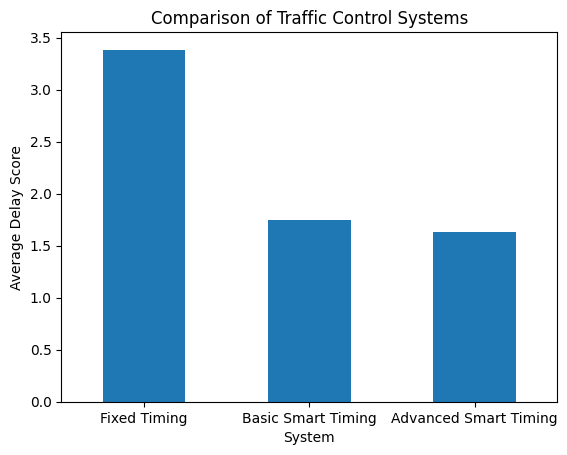

In [38]:
comparison = pd.DataFrame({
    "System": ["Fixed Timing", "Basic Smart Timing", "Advanced Smart Timing"],
    "Average Delay Score": [fixed_avg, smart_avg, advanced_avg]
})

comparison.plot(kind="bar", x="System", y="Average Delay Score", legend=False)

plt.ylabel("Average Delay Score")
plt.title("Comparison of Traffic Control Systems")
plt.xticks(rotation=0)
plt.show()

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("Data/Data December 2025.csv")

In [3]:
df.to_csv("traffic_output.csv", index=False)

In [5]:
df["Sdate"] = pd.to_datetime(df["Sdate"], dayfirst=True, errors="coerce")

In [6]:
df["Hour"] = df["Sdate"].dt.hour

In [7]:
df.to_csv("traffic_output.csv", index=False)

In [8]:
print(df.columns)
df.to_csv("traffic_output.csv", index=False)

Index(['Sdate', 'Cosit', 'Period', 'LaneNumber', 'LaneDescription',
       'LaneDirection', 'DirectionDescription', 'Volume', 'Flag Text', 'Hour'],
      dtype='str')


In [9]:
check = pd.read_csv("traffic_output.csv")
print(check.columns)
check.head()

Index(['Sdate', 'Cosit', 'Period', 'LaneNumber', 'LaneDescription',
       'LaneDirection', 'DirectionDescription', 'Volume', 'Flag Text', 'Hour'],
      dtype='str')


,Sdate,Cosit,Period,LaneNumber,LaneDescription,LaneDirection,DirectionDescription,Volume,Flag Text,Hour
0,2025-12-01 00:00:00,9913,60,2,Eastbound,2,NorthEast,14,Checked,0
1,2025-12-01 00:00:00,9913,60,1,Westbound,1,SouthWest,14,Checked,0
2,2025-12-01 01:00:00,9913,60,2,Eastbound,2,NorthEast,7,Checked,1
3,2025-12-01 01:00:00,9913,60,1,Westbound,1,SouthWest,8,Checked,1
4,2025-12-01 02:00:00,9913,60,2,Eastbound,2,NorthEast,5,Checked,2
